In [18]:
using Markdown
using Plots

In [256]:
function eulerMethod(f::Function, t0::Number, tf::Number, y0::Number, h::Number)
    n = round(Int, (tf - t0) / h)
    t = LinRange(t0, tf, n + 1)
    
    w = ones(length(t)) * y0

    for i in 1:length(t) - 1
        w[i + 1] = w[i] + h * f(t[i], w[i])
    end

    return t, w
end

eulerMethod (generic function with 1 method)

## Section 6.1: Computer Problem 10

In [257]:
f(x, y) = sinh(y)
actual_eq(t, ya, a, b) = 2 * atanh(exp(t - a)tanh(ya/2))

actual_eq (generic function with 1 method)

### Part A

In [258]:
h = [0.1 * (2.0)^(-k) for k in 0:5]
part_a = [eulerMethod(f, 0, 2, 0.25, x) for x in h]

6-element Vector{Tuple{LinRange{Float64, Int64}, Vector{Float64}}}:
 (LinRange{Float64}(0.0, 2.0, 21), [0.25, 0.27526123168081684, 0.30313627740463167, 0.333916304209811, 0.3679319316228832, 0.4055609016070193, 0.4472379460939193, 0.4934676785972197, 0.5448417141779341, 0.6020618067572789  …  0.737602065519326, 0.8182348776842556, 0.9094991729743294, 1.01351681094943, 1.1331334826209452, 1.27230094651989, 1.436744403571507, 1.6352082496265408, 1.8819889765868576, 2.202702261197454])
 (LinRange{Float64}(0.0, 2.0, 41), [0.25, 0.2626306158404084, 0.27591362564188865, 0.2898850147695892, 0.3045831201609205, 0.32004884118426785, 0.3363258775484822, 0.35346099875250436, 0.37150435044674296, 0.3905098041598715  …  1.2644234220791348, 1.3458896315761093, 1.435421996707801, 1.5345070646536305, 1.6450939720852396, 1.769806531442164, 1.9122903239327786, 2.0778111154896055, 2.274355196698423, 2.514824827361609])
 (LinRange{Float64}(0.0, 2.0, 81), [0.25, 0.2563153079202042, 0.2627935851433121, 0.26

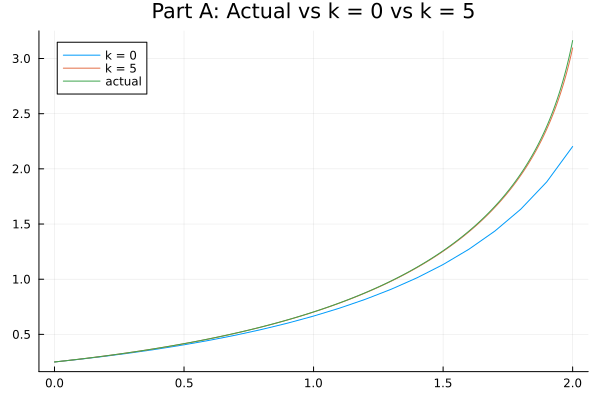

In [259]:
plot(part_a[1][1], part_a[1][2], label="k = 0")
plot!(part_a[6][1], part_a[6][2], label="k = 5")
plot!(part_a[6][1], (x) -> actual_eq(x, 1/4, 0, 2), label="actual")
title!("Part A: Actual vs k = 0 vs k = 5")

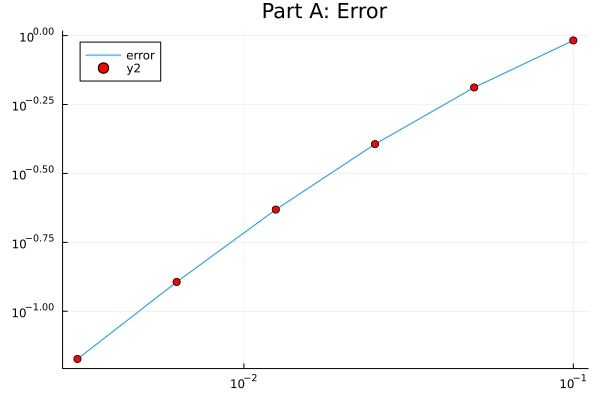

In [260]:
errors = [actual_eq(2, 1/4, 0, 2) - last(part_a[x][2]) for x in 1:6]

plot(h, errors, xscale=:log10, yscale=:log10, label="error")
title!("Part A: Error")

# Add points to the existing plot
scatter!(h, errors, markersize=4, color=:red)

### Part B

In [107]:
part_b = [eulerMethod(f, 0, 0.25, 2, x) for x in h]

6-element Vector{Tuple{LinRange{Float64, Int64}, Vector{Float64}}}:
 (LinRange{Float64}(0.0, 0.25, 3), [2.0, 2.362686040784702, 2.8889495644426604])
 (LinRange{Float64}(0.0, 0.25, 6), [2.0, 2.181343020392351, 2.3999756502571854, 2.6732803455102965, 3.0337400862979638, 3.5519063786492895])
 (LinRange{Float64}(0.0, 0.25, 11), [2.0, 2.0906715101961755, 2.1902557849962374, 2.3005759196815005, 2.424072511155817, 2.5641124032531644, 2.7255141115313624, 2.915498448136713, 3.1455463662771646, 3.4354128911162363, 3.8230630873434257])
 (LinRange{Float64}(0.0, 0.25, 21), [2.0, 2.0453357550980877, 2.0928508633530294, 2.142755000951873, 2.195289717969815, 2.2507351979560912, 2.3094188979646733, 2.37172673007554, 2.438117731952782, 2.5091436110159986  …  2.6679391880797874, 2.7575694798655137, 2.8556822420837045, 2.9639871061887875, 3.084758704259296, 3.2211115160238135, 3.377461791849868, 3.5603504326577005, 3.78001976251079, 4.053732796377865])
 (LinRange{Float64}(0.0, 0.25, 41), [2.0, 2.022667877

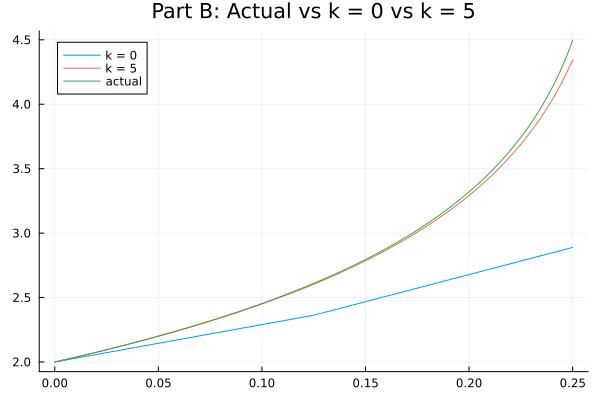

In [232]:
plot(part_b[1][1], part_b[1][2], label="k = 0")
plot!(part_b[6][1], part_b[6][2], label="k = 5")
plot!(part_b[6][1], (x) -> actual_eq(x, 2, 0, 0.25), label="actual")
title!("Part B: Actual vs k = 0 vs k = 5")

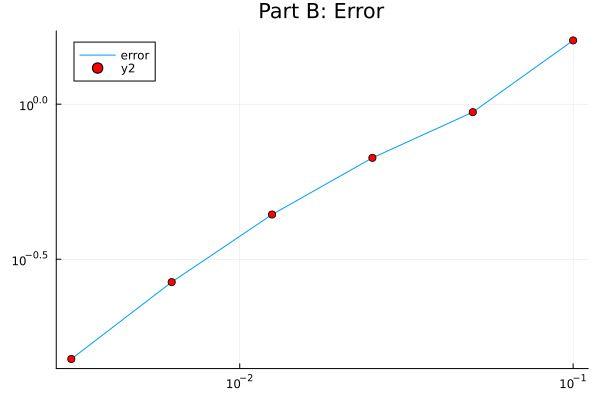

In [112]:
errors = [actual_eq(0.25, 2, 0, 0.25) - last(part_b[x][2]) for x in 1:6]

plot(h, errors, xscale=:log10, yscale=:log10, label="error")
title!("Part B: Error")


# Add points to the existing plot
scatter!(h, errors, markersize=4, color=:red)

## Section 6.2: Problem 5

1. Define $z(t)$ as the solution of the initial value problem: $y' = f(t, y), y(t_2) = w_2, t \in [t_2, t_3]$. $z(t_3)$ is the exact value of the solution starting at initial conditions $(t_2, w_2)$. $e_3 = |w_3 - z(t_3)|$ is the local truncation error of step $i = 3$. By Theorem 6.3, $|z(t_3) - y_3| \leq e^{Lh}g_2$ since $z$ and $y$ have different initial conditions. Thus
  
$$
\begin{align}
g_3 = |w_3 - y_3| &= |w_3 - z(t_3) + z(t_3) - y_3| \\
&\leq |w_3 - z(t_3)| + |z(t_3) - y_3| \text{    (By triangular inequality)} \\
&\leq e_3 + e^{Lh}g_2 \\
&\leq e_3 + e^{Lh}(e_2 + e^{Lh}e_1) \\
&\leq e_3 + e^{Lh}e_2 + e^{2Lh}e_1
\end{align}
$$

Thus $g_3 \leq e_3 + e^{Lh}e_2 + e^{2Lh}e_1$. 

2. **Base Case ($n = 1$)** At the initial condition, $y(a) = y_a$, the global error is $g_0 = |y_a - y_a| = 0 = e_0$. After 1 step, there is no accumulated error from the previous steps and the global error is equal to the local truncation erro so $g_1 = e_1 = |w_1 - y_1|$. $g_1 \leq |w_1 - y_1| + e^{Lh}e_0 = |w_1 - y_1|$. Thus for $k=1$, statement holds

**Inductive Hypothesis** Suppose $g_k \leq e_k + e^{Lh}e_{k - 1} + \ldots + e^{(k-1)Lh}e_1$

**Inductive Step** Say $n = k+1$. Define $z(t)$ as the solution of the initial value problem: $y' = f(t, y), y(t_k) = w_k, t \in [t_k, t_{k + 1}]$. $z(t_{k+1})$ is the exact value of the solution starting at initial conditions $(t_k, w_k)$. $e_{k + 1} = |w_{k + 1} - z(t_{k + 1})|$ is the local truncation error of step $i = 3$. By Theorem 6.3, $|z(t_{k + 1}) - y_{k + 1}| \leq e^{Lh}g_k$ since $z$ and $y$ have different initial conditions.

$$
\begin{align}
g_{k + 1} = |w_{k + 1} - y_{k + 1}| &= |w_{k + 1} - z(t_{k + 1}) + z(t_{k + 1}) - y_{k + 1}| \\
&\leq |w_{k + 1} - z(t_{k + 1})| + |z(t_{k + 1}) - y_{k + 1}| \text{    (By triangular inequality)} \\
&\leq e_{k + 1} + e^{Lh}g_k \\
&\leq e_{k + 1} + e^{Lh}(e_k + e^{Lh}e_{k - 1} + \ldots + e^{(k-1)Lh}e_1)  \text{    (By Inductive Hypothesis)}\\
&\leq e_3 + e^{Lh}e_k + e^{2Lh}e_{k - 1} + \ldots + e^{kLh}e_1
\end{align}
$$

Thus $g_{k + 1} \leq e_3 + e^{Lh}e_k + e^{2Lh}e_{k - 1} + \ldots + e^{kLh}e_1$.

Thus by induction, $g_k \leq e_k + e^{Lh}e_{k - 1} + \ldots + e^{(k-1)Lh}e_1$.

## Additional Problem

Implicit method based on Trapezoid Method

$y(t_{n + 1}) = y(t_n) + \int_{t_n}^{t_{n + 1}}(f(y(s), s))ds$

$\int_{t_n}^{t_{n + 1}}(f(y(s), s))ds \approx \frac{1}{2}h(f(y(t_n), t_n) + f(y(t_{n + 1}), t_n + h))$

$w(t_{n + 1}) = w_n + \frac{1}{2}h(f(w(t_n), t_n) + f(w(t_{n + 1}), t_n + h))$

$w_{n} := w(t_n)$

$f_n(x) := f(x, t_n) = f(x, t_{n - 1} + h)$

$F(w_{n + 1}) = w_n + \frac{1}{2}h(f(w_n, t_n) + f_{n + 1}(w_{n + 1})) - w_{n + 1}$

$t_n + h$ is constant

$F'(w_{n + 1}) = 0.5hf_{n + 1}'(w_{n + 1})) - 1$

$w_{n + 1}^{(k)}$ is kth iteration of Newton's Method to find $w_{n + 1}$

$w_{n + 1}^{(0)} = w_{n}$

$w_{n + 1}^{(k + 1)} := w_{n + 1}^{(k)} - \frac{F(w_{n + 1}^{(k)})}{F'(w_{n + 1}^{(k)})} = w_{n + 1}^{(k)} - \frac{w_n + \frac{1}{2}h(f(w_n, t_n) + f_{n + 1}(w_{n + 1}^{(k)})) - w_{n + 1}^{(k)}}{0.5hf_{n + 1}'(w_{n + 1}^{(k)})) - 1}$

$w_{n + 1}^{(0)} = w_n + f(t_n, w_n)$




Note in part A and part B, the last point when k = 0, the solver displays some weird behaviour. This may be because that the derivative at such a point or in its iterations went too close to 0 and thus the newton's method solver sent the point too far negative.

In [254]:
function newtons(f:: Function, derivative:: Function, x0 :: Float64, tol::Float64 = 0.5 * 10^-8, maxIter = nothing)
    xi = x0
	value = f(xi)
    
	iter = 0
	
	# If max iteration set otherwise simply continue till tolerance is satisfied
	while (maxIter != nothing && iter < maxIter) || (maxIter == nothing)
		xLast = xi
		xi = xLast - value/derivative(xLast)
		value = f(xi)

		if abs(xi - xLast) < tol || abs(value) <= tol
			break
		end
		iter+=1
	end

	return (xi, value)
end

newtons (generic function with 3 methods)

In [255]:
function implicit_trapezoid(f::Function, t0::Number, tf::Number, y0::Number, h::Number, f_diff_y::Function, tol::Float64 = 0.5 * 10^-8, maxIter = nothing)
    n = round(Int, (tf - t0) / h)
    t = LinRange(t0, tf, n + 1)
    
    w = ones(length(t)) * y0

    for i in 2:length(t)
        F(y) = w[i - 1] + 0.5*h*(f(t[i - 1], w[i - 1]) + f(t[i], y)) - y
        F_prime(y) = 0.5*h*f_diff_y(t[i - 1], y) - 1
        w[i] = newtons(F, F_prime, w[i - 1] + h * f(t[i - 1], w[i - 1]), tol, maxIter)[1]
    end
    
    return t, w

end

implicit_trapezoid (generic function with 3 methods)

In [247]:
f_diff_y(t, y) = cosh(y)

f_diff_y (generic function with 1 method)

In [248]:
h = [0.1 * (2.0)^(-k) for k in 0:5]
implicit_part_a = [implicit_trapezoid(f, 0, 2, 0.25, x, f_diff_y, 0.5 * 10^-12) for x in h]

6-element Vector{Tuple{LinRange{Float64, Int64}, Vector{Float64}}}:
 (LinRange{Float64}(0.0, 2.0, 21), [0.25, 0.27663970319770426, 0.3061991081905775, 0.33902739758567746, 0.37552610184383883, 0.4161607157734838, 0.46147613589573555, 0.5121175740449662, 0.568859490553348, 0.6326465638714142  …  0.7863730080345624, 0.8797568886127374, 0.9874381057323627, 1.1131159334886878, 1.2622576763172315, 1.4435021564589459, 1.6718382675878023, 1.97731050176274, 2.4387045706042136, -5.835851339796353])
 (LinRange{Float64}(0.0, 2.0, 41), [0.25, 0.2629654750477031, 0.27661966562505835, 0.2910018485842805, 0.3061539855564854, 0.32212097800265177, 0.3389509569946057, 0.356695613829045, 0.37541057885117823, 0.395155857446246  …  1.3440893722050262, 1.4384755359481782, 1.544063656306864, 1.6635461671680798, 1.8007667151406281, 1.9614971046591883, 2.155015032007732, 2.3977616209024837, 2.7237541036618436, 3.2283952348863525])
 (LinRange{Float64}(0.0, 2.0, 81), [0.25, 0.256397858547598, 0.2629631161877324,

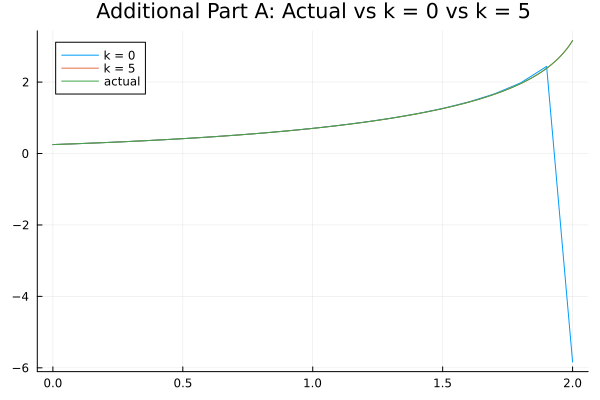

In [249]:
plot(implicit_part_a[1][1], implicit_part_a[1][2], label="k = 0")
plot!(implicit_part_a[6][1], implicit_part_a[6][2], label="k = 5")
plot!(implicit_part_a[6][1], (x) -> actual_eq(x, 1/4, 0, 2), label="actual")
title!("Additional Part A: Actual vs k = 0 vs k = 5")

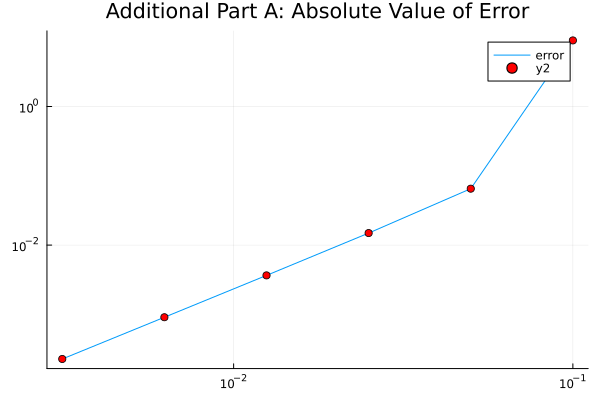

In [250]:
errors = abs.([actual_eq(2, 1/4, 0, 2) - last(implicit_part_a[x][2]) for x in 1:6])

plot(h, errors, xscale=:log10, yscale=:log10, label="error")
title!("Additional Part A: Absolute Value of Error")

# Add points to the existing plot
scatter!(h, errors, markersize=4, color=:red)

In [251]:
implicit_part_b = [implicit_trapezoid(f, 0, 0.25, 2, x, f_diff_y, 0.5 * 10^-12) for x in h]

6-element Vector{Tuple{LinRange{Float64, Int64}, Vector{Float64}}}:
 (LinRange{Float64}(0.0, 0.25, 3), [2.0, 2.4768293662635155, -5.842354459672979])
 (LinRange{Float64}(0.0, 0.25, 6), [2.0, 2.202370114303975, 2.4591918729783253, 2.811499040244037, 3.388547108978013, -6.73254126690948])
 (LinRange{Float64}(0.0, 0.25, 11), [2.0, 2.0953696312269514, 2.2011850246732685, 2.3199468860181556, 2.455195102372842, 2.612184310789095, 2.7992246752697554, 3.0306887710592516, 3.335122704468425, 3.7856798520329793, 4.901328769997158])
 (LinRange{Float64}(0.0, 0.25, 21), [2.0, 2.0464528899395216, 2.095251802248575, 2.1466381054304744, 2.2008929194571722, 2.2583463682735188, 2.319389694934022, 2.384491374293321, 2.4542189213983043, 2.5292690015781503  …  2.699043478365185, 2.7962967963656924, 2.904165678480709, 3.025246130714898, 3.163230854588426, 3.323636074828099, 3.5152612579029956, 3.7535191303120365, 4.069669343503594, 4.547501061894242])
 (LinRange{Float64}(0.0, 0.25, 41), [2.0, 2.0229405930740

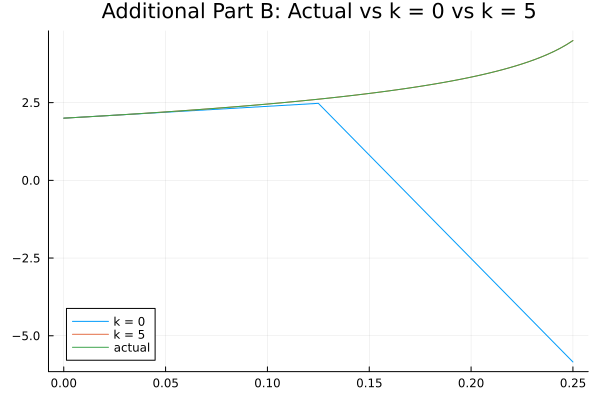

In [252]:
plot(implicit_part_b[1][1], implicit_part_b[1][2], label="k = 0")
plot!(implicit_part_b[6][1], implicit_part_b[6][2], label="k = 5")
plot!(implicit_part_b[6][1], (x) -> actual_eq(x, 2, 0, 0.25), label="actual")
title!("Additional Part B: Actual vs k = 0 vs k = 5")

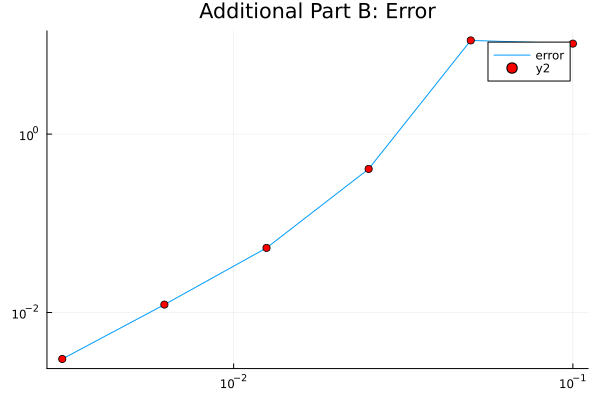

In [253]:
errors = abs.([actual_eq(0.25, 2, 0, 0.25) - last(implicit_part_b[x][2]) for x in 1:6])

plot(h, errors, xscale=:log10, yscale=:log10, label="error")
title!("Additional Part B: Error")


# Add points to the existing plot
scatter!(h, errors, markersize=4, color=:red)